# Renewable Energy Profiles Dataset Construction

## Overview

This notebook constructs gridded **renewable energy profiles** (capacity factors and installable potentials) from PyPSA-Earth data. These profiles represent **onwind**, **offwind-ac**, and **solar** renewable generation potential across geographic regions.

### What We Build

For each renewable technology and geographic location (bus), we extract:
- **Capacity Factor** (cf): Hourly time series of energy output (0-1) across 8,760 hours
- **p_nom_max**: Maximum installable power capacity (MW) based on land/sea availability
- **Potential**: Grid-level renewable resource (GW per 0.25° × 0.25° cell)
- **Geometry**: Bus region boundaries (Voronoi polygons as GeoJSON)

### Outputs

The workflow produces **three output files**:
1. **NetCDF** (.nc): Time series + potentials + metadata for all buses/technologies
2. **GeoJSON** (.geojson): Geographic boundaries + attributes (bus_id, country, area, density)
3. **Metadata** (metadata.json): Schema version + timestamp + file manifest

These are used downstream for energy system modeling (PyPSA) and renewable energy supply curves.

### Workflow

1. **Setup**: Initialize paths and logging (idempotent, safe to rerun)
2. **Load Data**: Load raw PyPSA-Earth profiles and region boundaries
3. **Build Profiles**: 7-stage pipeline transforms raw data into per-bus profiles
4. **Save**: Write NetCDF + GeoJSON + metadata with reproducibility tags
5. **Inspect**: Verify dataset structure and summary statistics
6. **Validate**: Check data quality (capacity factor ranges, completeness)
7. **Visualize**: Plot grid-level potential and bus-level capacity density

In [1]:
# ===== SETUP: Environment Paths (Idempotent) =====
"""
Set up paths relative to notebook location. This is idempotent - won't break on rerun.
Uses the notebook file itself as an anchor point instead of working directory.
"""

import os
import sys
from pathlib import Path
import logging

# Get notebook directory (more reliable than os.getcwd() which changes with os.chdir)
NOTEBOOK_DIR = Path(globals().get("_dh", [os.getcwd()])[0])  # Jupyter provides _dh
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()

# Compute shift path (3 levels up from notebook: notebooks/ → workflow/ → shift/)
SHIFT_PATH = NOTEBOOK_DIR.parent.parent.parent
if not (SHIFT_PATH / ".gitignore").exists():
    # Fallback if structure is different
    SHIFT_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), "../../..", "shift")))

SHIFT_PATH = SHIFT_PATH.resolve()
PYPSA_EARTH_PATH = SHIFT_PATH.parent / "pypsa-earth"

# Validate paths
if not SHIFT_PATH.is_dir():
    raise FileNotFoundError(f"shift not found at {SHIFT_PATH}")
if not PYPSA_EARTH_PATH.is_dir():
    raise FileNotFoundError(f"pypsa-earth not found at {PYPSA_EARTH_PATH}")

# Add to sys.path only if not already present (idempotent)
for path in [str(SHIFT_PATH), str(PYPSA_EARTH_PATH)]:
    if path not in sys.path:
        sys.path.append(path)

# ===== SETUP: Logging Configuration =====
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)
logger.info("✓ Paths configured:")
logger.info(f"  SHIFT_PATH: {SHIFT_PATH}")
logger.info(f"  PYPSA_EARTH_PATH: {PYPSA_EARTH_PATH}")

2026-04-17 15:25:45,698 - __main__ - INFO - ✓ Paths configured:
2026-04-17 15:25:45,700 - __main__ - INFO -   SHIFT_PATH: C:\Users\JanLeopoldTautorus\Repos\shift
2026-04-17 15:25:45,701 - __main__ - INFO -   PYPSA_EARTH_PATH: C:\Users\JanLeopoldTautorus\Repos\pypsa-earth


In [31]:
# ===== IMPORTS =====
import importlib
import matplotlib.pyplot as plt

import workflow.scripts.renewable_profiles as renewable_profiles

importlib.reload(renewable_profiles)

# Import module functions
load_pypsa_earth_profiles = renewable_profiles.load_pypsa_earth_profiles
load_region_boundaries = renewable_profiles.load_region_boundaries
build_profiles = renewable_profiles.build_profiles
save_profiles = renewable_profiles.save_profiles
load_profiles = renewable_profiles.load_profiles
audit_profiles_against_raw = renewable_profiles.audit_profiles_against_raw
plot_grid_potentials = renewable_profiles.plot_grid_potentials
plot_bus_capacity_density = renewable_profiles.plot_bus_capacity_density

In [3]:
# ===== LOAD DATA: PyPSA-Earth Profiles & Regions =====
"""
Load renewable technology profiles and geographic region boundaries.
Uses the preprocessing script functions.
"""
logger.info("=" * 70)
logger.info("LOADING RAW DATA")
logger.info("=" * 70)

# Load technology profiles
tech_profiles_nc = load_pypsa_earth_profiles(PYPSA_EARTH_PATH)

# Load region boundaries
onshore_regions_gpd, offshore_regions_gpd = load_region_boundaries(PYPSA_EARTH_PATH)

logger.info(
    f"✓ Data loaded: {len(tech_profiles_nc)} technologies, "
    f"{len(onshore_regions_gpd)} onshore, {len(offshore_regions_gpd)} offshore regions"
)

2026-04-17 15:25:47,461 - __main__ - INFO - ======================================================================
2026-04-17 15:25:47,462 - __main__ - INFO - LOADING RAW DATA
2026-04-17 15:25:47,462 - __main__ - INFO - ======================================================================
2026-04-17 15:25:47,464 - workflow.scripts.renewable_profiles - INFO - Loading renewable technology profiles from PyPSA-Earth...
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
2026-04-17 15:25:47,763 - workflow.scripts.renewable_profiles - INFO -   ✓ onwind: 8760 hours, 4582 buses, grid 259×243
2026-04-17 15:25:47,777 - workflow.scripts.renewable_profiles - INFO -   ✓ offwind-ac: 8760 hours, 713 buses, grid 290×256
2026-04-17 15:25:47,793 - workflow.scripts.renewable_profiles - INFO -   ✓ s

In [4]:
# ===== BUILD PROFILES: 7-Stage Pipeline =====
"""
Main orchestrator: builds per-bus renewable profiles from PyPSA-Earth data.

Configuration options:
- country_codes: Filter to specific countries (None = all)
- geohash_precision: Bus ID precision (1-12, default 6)
- process_by_country: Sequential processing to reduce memory (default True)
"""
logger.info("=" * 70)
logger.info("BUILDING RENEWABLE PROFILES (7-Stage Pipeline)")
logger.info("=" * 70)

# Configuration
config = {
    "country_codes": None,  # None = process all regions
    "geohash_precision": 6,
    "process_by_country": True,  # Sequential reduces memory usage
}

# Build profiles
profiles_ds, geometry_gdf = build_profiles(
    tech_profiles_nc,
    onshore_regions_gpd,
    offshore_regions_gpd,
    config=config,
)

logger.info(
    f"✓ Built {len(profiles_ds.bus)} buses × {len(profiles_ds.technology)} technologies"
)

2026-04-17 15:25:48,031 - __main__ - INFO - ======================================================================
2026-04-17 15:25:48,032 - __main__ - INFO - BUILDING RENEWABLE PROFILES (7-Stage Pipeline)
2026-04-17 15:25:48,033 - __main__ - INFO - ======================================================================
2026-04-17 15:25:48,034 - workflow.scripts.renewable_profiles - INFO - Building profiles for: ['onwind', 'offwind-ac', 'solar']
2026-04-17 15:25:48,034 - workflow.scripts.renewable_profiles - INFO - STAGE 0: Prepare regions
2026-04-17 15:25:48,083 - workflow.scripts.renewable_profiles - INFO - Combined: 5296 total regions
2026-04-17 15:25:48,085 - workflow.scripts.renewable_profiles - INFO - STAGE 1: Generate bus IDs
C:\Users\JanLeopoldTautorus\Repos\shift\workflow\scripts\renewable_profiles.py:194: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this o

In [12]:
# ===== DIAGNOSTIC: Processed vs Raw Stats (potential, p_nom_max) =====
"""
Compare processed dataset statistics against raw PyPSA-Earth inputs.
Metrics: min, max, mean, NaN count, NaN share.
"""

audit_report = audit_profiles_against_raw(
    profiles_ds=profiles_ds,
    raw_profile_datasets=tech_profiles_nc,
    logger_instance=logger,
)

2026-04-17 15:32:46,713 - __main__ - INFO - ======================================================================
2026-04-17 15:32:46,714 - __main__ - INFO - PROCESSED vs RAW AUDIT
2026-04-17 15:32:46,714 - __main__ - INFO - ======================================================================
2026-04-17 15:32:46,715 - __main__ - INFO - 
----------------------------------------------------------------------
2026-04-17 15:32:46,716 - __main__ - INFO - Technology: onwind
2026-04-17 15:32:46,717 - __main__ - INFO - ----------------------------------------------------------------------
2026-04-17 15:32:46,720 - __main__ - INFO - potential stats
2026-04-17 15:32:46,720 - __main__ - INFO -   processed: min=0, max=3958.24, mean=1149.4, NaN=11303/74240 (15.22%)
2026-04-17 15:32:46,721 - __main__ - INFO -   raw:       min=0, max=3958.24, mean=1149.4, NaN=0/62937 (0.00%)
2026-04-17 15:32:46,723 - __main__ - INFO - p_nom_max stats
2026-04-17 15:32:46,723 - __main__ - INFO -   processed: min=0, 

In [14]:
# ===== SAVE PROFILES =====
"""
Save output as NetCDF + GeoJSON + metadata.json for reproducibility.
"""
logger.info("=" * 70)
logger.info("SAVING PROFILES")
logger.info("=" * 70)

output_dir = SHIFT_PATH / "data" / "renewable_profiles"
nc_path, geojson_path, metadata_path = save_profiles(
    profiles_ds,
    geometry_gdf,
    output_dir=output_dir,
    filename_prefix="renewable_profiles_africa",
)

logger.info(f"✓ Saved to {output_dir}")
logger.info(f"  - {Path(nc_path).name}")
logger.info(f"  - {Path(geojson_path).name}")
logger.info(f"  - {Path(metadata_path).name}")

2026-04-17 15:02:24,289 - __main__ - INFO - ======================================================================
2026-04-17 15:02:24,289 - __main__ - INFO - SAVING PROFILES
2026-04-17 15:02:24,290 - __main__ - INFO - ======================================================================
2026-04-17 15:02:24,292 - workflow.scripts.renewable_profiles - INFO - Saving NetCDF to C:\Users\JanLeopoldTautorus\Repos\shift\data\renewable_profiles\renewable_profiles_africa__20260417_150224.nc
2026-04-17 15:02:31,403 - workflow.scripts.renewable_profiles - INFO - Saving GeoJSON to C:\Users\JanLeopoldTautorus\Repos\shift\data\renewable_profiles\renewable_profiles_africa__20260417_150224.geojson
2026-04-17 15:02:31,716 - pyogrio._io - INFO - Created 5,296 records
2026-04-17 15:02:31,717 - workflow.scripts.renewable_profiles - INFO - Saving metadata to C:\Users\JanLeopoldTautorus\Repos\shift\data\renewable_profiles\renewable_profiles_africa__20260417_150224_metadata.json
2026-04-17 15:02:31,719 - wo

In [8]:
# ===== INSPECT OUTPUT DATASET =====
"""
Display dataset structure and summary statistics.
"""
logger.info("=" * 70)
logger.info("OUTPUT DATASET SUMMARY")
logger.info("=" * 70)
logger.info(f"\n{profiles_ds}")

logger.info("\n" + "=" * 70)
logger.info("DATA VARIABLES")
logger.info("=" * 70)
logger.info(f"Total buses:       {len(profiles_ds.bus):,}")
logger.info(f"Technologies:      {list(profiles_ds.technology.values)}")
logger.info(f"Hours per year:    {len(profiles_ds.hour)}")
logger.info(f"Variables:         {list(profiles_ds.data_vars.keys())}")

# Show first 3 buses
logger.debug("\n" + "-" * 70)
logger.debug("SAMPLE: First 3 buses")
logger.debug("-" * 70)

logger.info("✓ Dataset inspection complete")

2026-04-17 15:31:15,815 - __main__ - INFO - ======================================================================
2026-04-17 15:31:15,816 - __main__ - INFO - OUTPUT DATASET SUMMARY
2026-04-17 15:31:15,817 - __main__ - INFO - ======================================================================
2026-04-17 15:31:15,823 - __main__ - INFO - 
<xarray.Dataset> Size: 558MB
Dimensions:            (bus: 5296, technology: 3, hour: 8760, y_grid: 256,
                        x_grid: 290)
Coordinates:
  * bus                (bus) object 42kB 'GNQ_ON_s0r8wu' ... 'MUS_OFF_mk155c'
  * technology         (technology) <U10 120B 'onwind' 'offwind-ac' 'solar'
  * hour               (hour) int32 35kB 0 1 2 3 4 ... 8755 8756 8757 8758 8759
  * y_grid             (y_grid) float64 2kB -37.5 -37.2 -36.9 ... 38.4 38.7 39.0
  * x_grid             (x_grid) float64 2kB -19.5 -19.2 -18.9 ... 66.6 66.9 67.2
Data variables:
    capacity_factor    (bus, technology, hour) float32 557MB 0.01312 ... nan
    p_nom_max  

2026-04-17 15:37:52,698 - workflow.scripts.renewable_profiles - WARNING - No Natural Earth country match for: ['KM', 'MU', 'SC', 'ST']. These labels are ignored for extent calculation.
2026-04-17 15:37:52,700 - workflow.scripts.renewable_profiles - INFO - Computed extent from 34 matched countries [min_lon, max_lon, min_lat, max_lat]: [-18.02, 52.13, -35.82, 38.35]
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


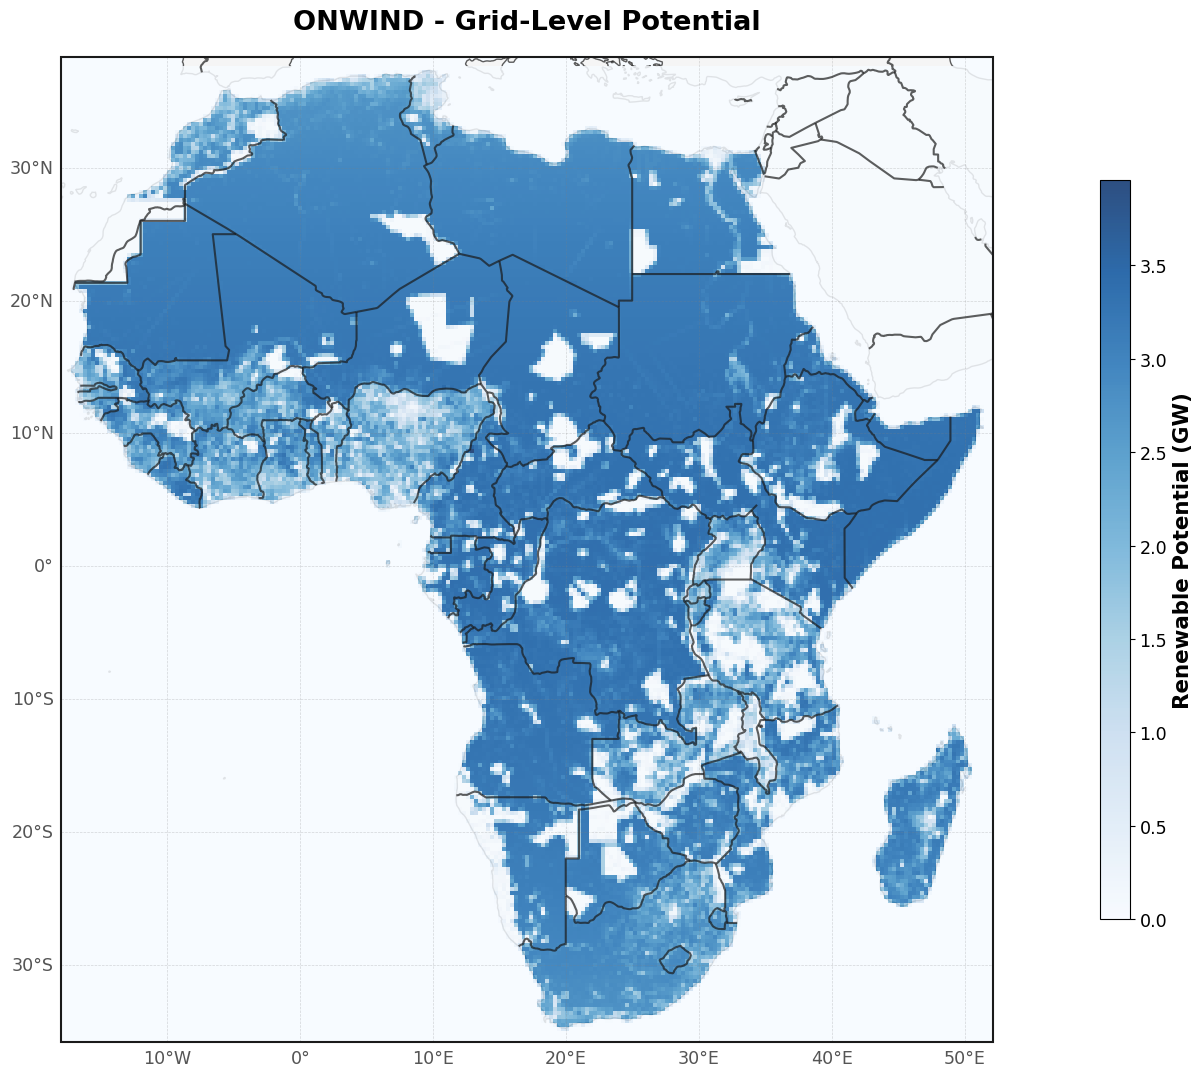

In [19]:
# Grid-level raster map (GW per 0.25° grid cell)
fig1, ax1 = plot_grid_potentials(
    profiles_ds,
    technology="onwind",
    region=[
        "BI",
        "KM",
        "DJ",
        "ER",
        "ET",
        "KE",
        "MG",
        "MW",
        "MU",
        "MZ",
        "RW",
        "SC",
        "SO",
        "SS",
        "TZ",
        "UG",
        "ZM",
        "ZW",  # Africa — Eastern Africa
        "AO",
        "CM",
        "CF",
        "TD",
        "CG",
        "CD",
        "GQ",
        "GA",
        "ST",  # Africa — Middle Africa
        "DZ",
        "EG",
        "LY",
        "MA",
        "SD",
        "TN",  # Africa — Northern Africa
        "BW",
        "SZ",
        "LS",
        "NA",
        "ZA",  # Africa — Southern Africa
    ],
    cmap="Blues",
    gridlabels=True,
    filename=None,  # Set to "onwind_grid.png" to save
)
plt.tight_layout()
plt.show()

2026-04-17 15:46:41,109 - workflow.scripts.renewable_profiles - INFO - Region not specified. Using all countries from geometry_gdf: ['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LBY', 'LSO', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'TCD', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']
2026-04-17 15:46:41,172 - workflow.scripts.renewable_profiles - WARNING - No Natural Earth country match for: ['COM', 'CPV', 'MUS', 'STP', 'SYC']. These labels are ignored for extent calculation.
2026-04-17 15:46:41,174 - workflow.scripts.renewable_profiles - INFO - Computed extent from 49 matched countries [min_lon, max_lon, min_lat, max_lat]: [-18.63, 52.13, -35.82, 38.35]
c:\Users\JanLeopoldTautorus\Repos\shift\.pixi\envs\dev\Lib\site-packages\cartopy\mpl\feature_artist.py:143: Use

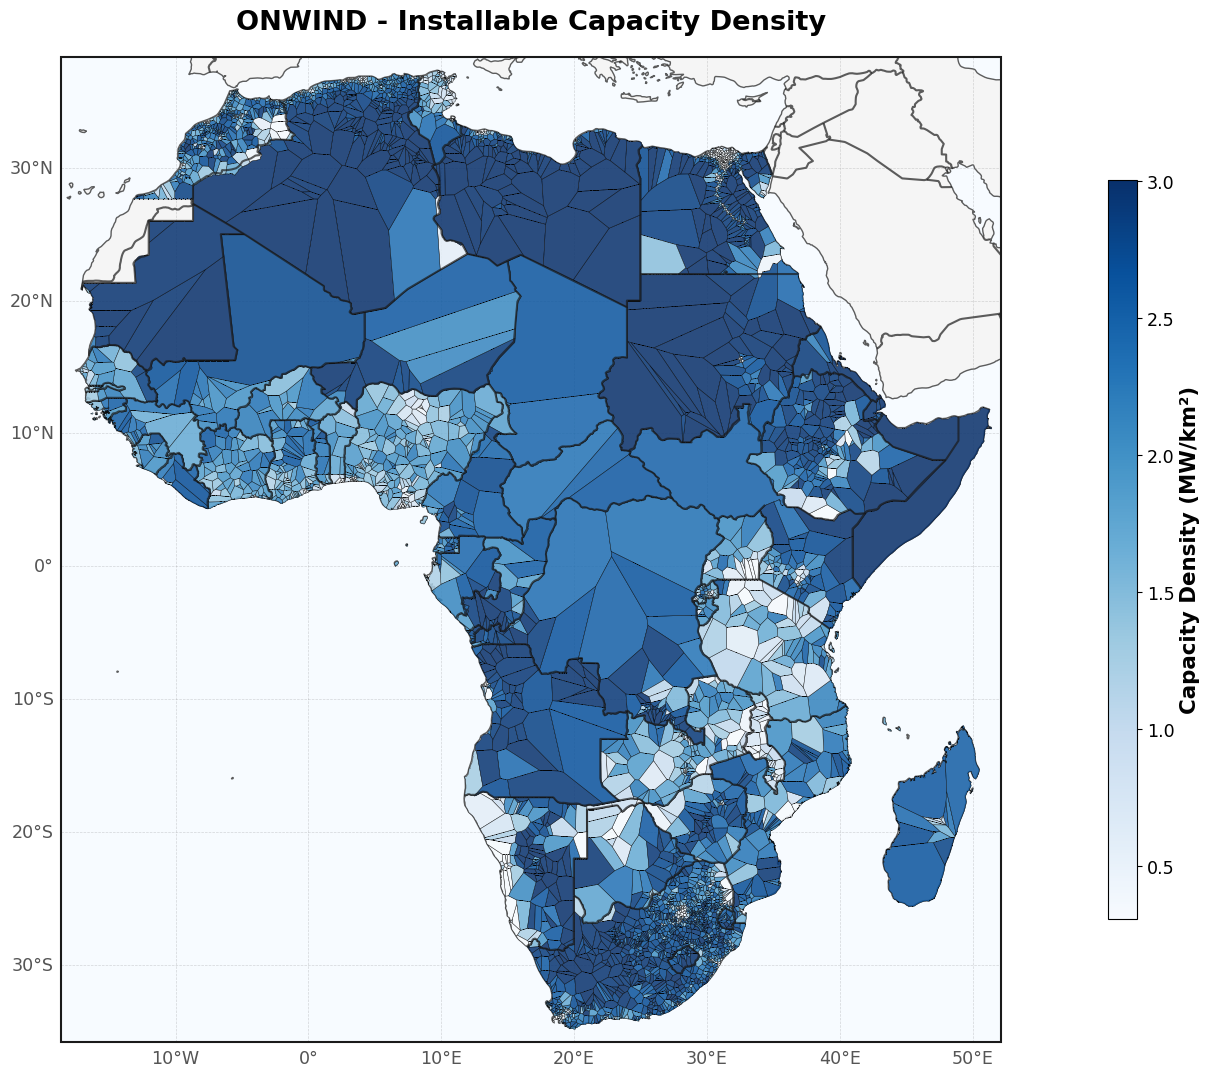

In [32]:
# Bus-level capacity density map (GW/km² per Voronoi region)
# Pass geometry_gdf for better performance (uses GeoJSON directly)
fig2, ax2 = plot_bus_capacity_density(
    profiles_ds,
    technology="onwind",
    geometry_gdf=geometry_gdf,  # Optional: pass GeoDataFrame for faster geometry lookup
    cmap="Blues",
    vmin=None,  # Auto-scale to 5-95 percentile
    vmax=None,
    gridlabels=True,
    filename=None,  # Set to "onwind_density.png" to save
)
plt.tight_layout()
plt.show()